# Decoherence Simulation via the Lindblad Master Equation

## Overview

This notebook simulates the decoherence of a quantum harmonic oscillator coupled to an environment, using the **Lindblad master equation** framework. The simulation is built on two custom modules:

- `QuantumSimulator.py` — discretises the harmonic oscillator on a position grid, builds the Hamiltonian, computes eigenstates, and evolves pure states via a Trotter decomposition of the time-evolution operator.
- `lindblad_extension.py` — extends the simulator to open quantum systems by evolving density matrices $\rho$ under the Lindblad master equation using 4th-order Runge-Kutta.

---

## Theory

### Closed system dynamics

For a closed quantum system, the state is described by a wavefunction $\psi(x, t)$ evolving under the Schrödinger equation:

$$i\hbar \frac{\partial \psi}{\partial t} = \hat{H} \psi$$

with the harmonic oscillator Hamiltonian:

$$\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}\omega^2 x^2$$

### Open system dynamics

When the system interacts with an environment, the state can no longer be described by a pure wavefunction. Instead, we use the **density matrix** $\rho$, which evolves under the **Lindblad master equation**:

$$\frac{d\rho}{dt} = -i[\hat{H}, \rho] + \sum_k \gamma_k \mathcal{D}[L_k](\rho)$$

where the **Lindblad dissipator** is:

$$\mathcal{D}[L](\rho) = L\rho L^\dagger - \frac{1}{2}\left(L^\dagger L \rho + \rho L^\dagger L\right)$$

### Jump operators

Two physical noise channels are included:

| Channel | Jump operator | Rate | Physical meaning |
|---|---|---|---|
| **Dephasing** | $L = \hat{x}$ | $\gamma_\phi = 0.05$ | Environment continuously monitors position, destroying phase coherence |
| **Amplitude damping** | $L = \hat{a}$ | $\gamma_d = 0.02$ | Energy dissipation into the environment (e.g. photon loss from a cavity) |

### Initial state

For this notebook demo, the system is initialised in a **coherent state** $|\alpha\rangle$ centred at $x_0 = 2$:

$$\psi_0(x) = \left(\frac{\omega}{\pi}\right)^{1/4} \exp\!\left(-\frac{\omega}{2}(x - x_0)^2\right)$$

A coherent state is the most "classical" pure quantum state — a minimum-uncertainty Gaussian that follows the classical trajectory in phase space. The initial density matrix is $\rho_0 = |\psi_0\rangle\langle\psi_0|$.

---

## Diagnostics

The simulation tracks four observables over time:

- **Purity** $\gamma = \mathrm{Tr}(\rho^2) \in (0, 1]$ — equals 1 for a pure state, decreases as the state mixes
- **Von Neumann entropy** $S = -\mathrm{Tr}(\rho \ln \rho)$ — zero for pure states, increases with decoherence
- **Mean position** $\langle x \rangle = \mathrm{Tr}(\hat{x}\,\rho)$ — tracks the classical oscillation, damped by amplitude damping
- **Position variance** $\mathrm{Var}(x) = \langle x^2 \rangle - \langle x \rangle^2$ — starts at the coherent-state value of $1/2\omega$, grows due to dephasing-induced momentum diffusion

The **Wigner quasi-probability distribution** $W(x, p)$ is also computed at the initial and final times, providing a phase-space portrait of the quantum state. Negative regions of $W$ signal non-classical coherence; their disappearance marks the quantum-to-classical transition.

In [50]:
import QuantumSimulator as sim
import lindblad_extension as lindblad
import importlib

importlib.reload(sim)
importlib.reload(lindblad)

from QuantumSimulator import *
from lindblad_extension import LindbladSolver


In [ ]:
import numpy as np

#  set up the simulator
sim = Quantum_numerical_simulator(L=200, x_min=-8, x_max=8)
sim.discrete_Potential(omega=1.0)
sim.build_hamiltonian()
sim.compute_eigenstates(verbose=False)
# create initial state and attach Lindblad solver
psi0 = sim.coherent_state(x0=2.0, p0=0.0)
rho0 = np.outer(psi0, psi0.conj())

#  simulating decoherence with Lindblad master equation 
solver = LindbladSolver(sim)
solver.build_jump_operators(gamma_dephasing=0.05, gamma_damping=0.02, n_fock=80)



[Lindblad] Dephasing   L = x̂,  γ = 0.05
[Lindblad] Damping     L = â,   γ = 0.02


[(array([[-8.        +0.j,  0.        +0.j,  0.        +0.j, ...,
           0.        +0.j,  0.        +0.j,  0.        +0.j],
         [ 0.        +0.j, -7.91959799+0.j,  0.        +0.j, ...,
           0.        +0.j,  0.        +0.j,  0.        +0.j],
         [ 0.        +0.j,  0.        +0.j, -7.83919598+0.j, ...,
           0.        +0.j,  0.        +0.j,  0.        +0.j],
         ...,
         [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
           7.83919598+0.j,  0.        +0.j,  0.        +0.j],
         [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
           0.        +0.j,  7.91959799+0.j,  0.        +0.j],
         [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
           0.        +0.j,  0.        +0.j,  8.        +0.j]]),
  0.05),
 (array([[-1.75201265e+00+0.j, -2.30211274e+00+0.j, -1.39728889e+00+0.j,
          ..., -8.26476491e-03+0.j,  3.31572598e-02+0.j,
           3.73876892e-02+0.j],
         [-2.34722427e+00+0.j, -3.22595550e+0

In [56]:
#  evolve
T_cl = 2 * np.pi / sim.omega
times, rhos = solver.evolve(rho0, t_total=3*T_cl, dt=0.005, stride=5)

[Lindblad] Evolving: 3769 steps,  dt = 0.005,  stride = 5 …
[Lindblad] Evolution complete.


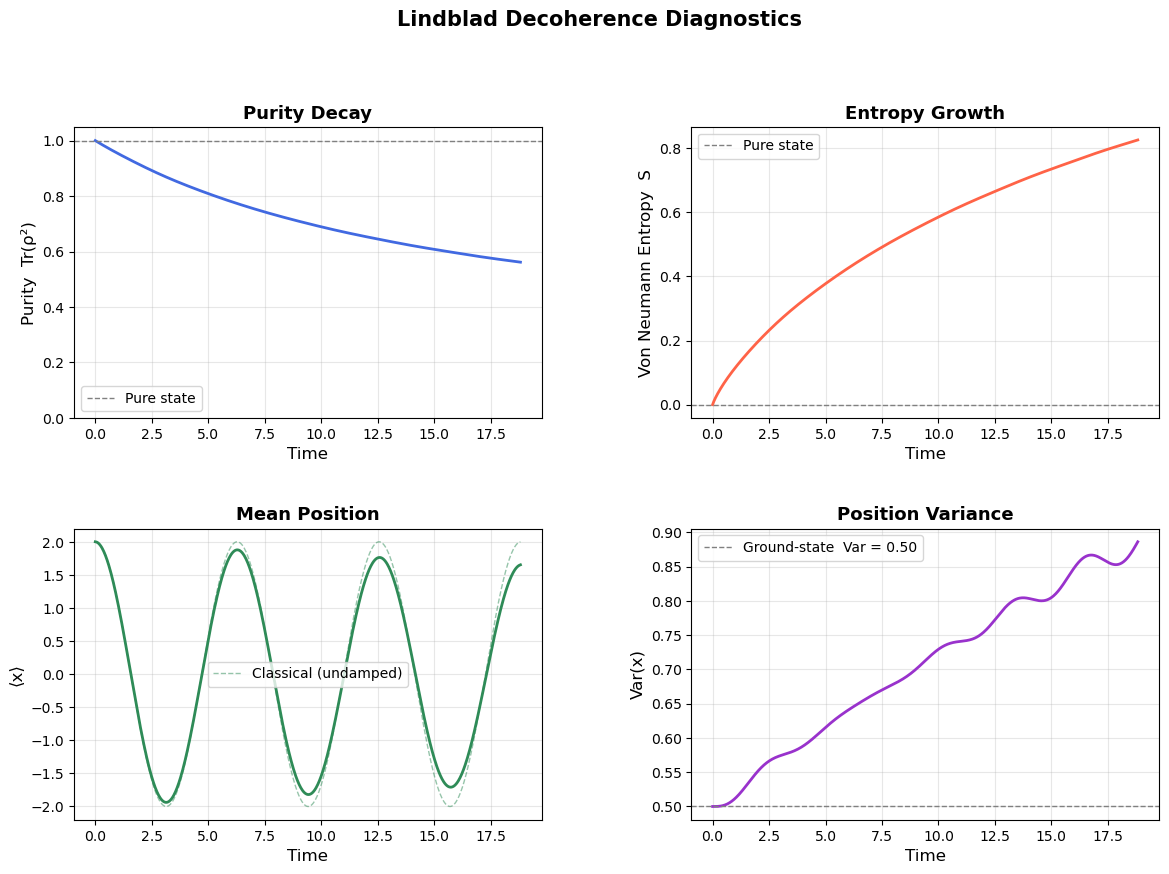

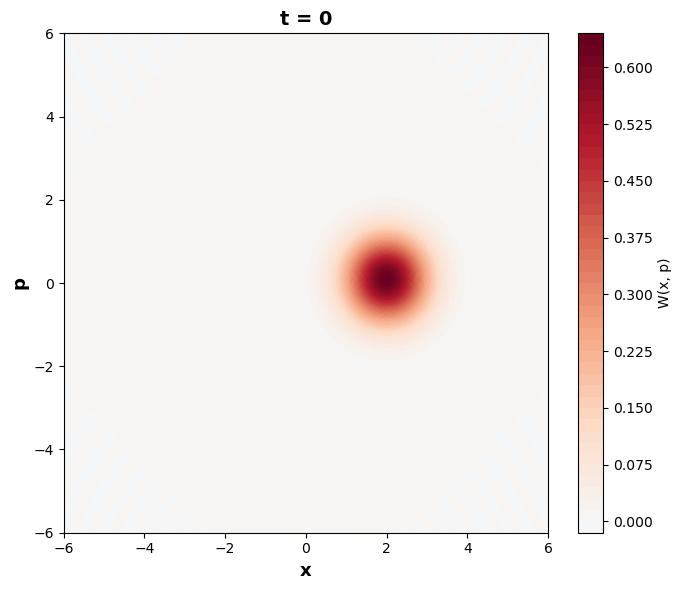

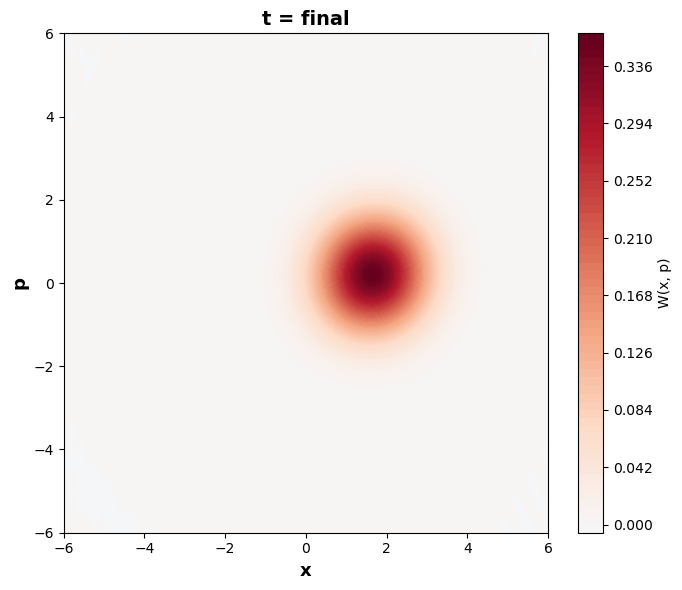

In [57]:
solver.plot_diagnostics(times, rhos)
solver.plot_wigner_dm(rhos[0], title='t = 0')
solver.plot_wigner_dm(rhos[-1], title='t = final')